# 05 — Machine Learning: LTV, Segmentation & Upsell Models

**Customer Subscription & Churn Intelligence Platform**
**Phase 5 of 6 — Remaining Predictive & Unsupervised Models**

---

## Objective

Notebook 4 covered churn prediction in depth. This notebook reproduces the three remaining models in
`src/ml/`: **LTV regression** (`ltv_model.py`), **customer segmentation** (`segmentation.py`), and the
**upsell recommendation system** (`upsell_model.py`) — three genuinely different modeling problems
(regression, unsupervised clustering, and a per-service classification ensemble), each reproduced in
full with real outputs, and each with at least one added visualization or improvement the original
module didn't include.

By the end of this notebook we will have:

1. Trained and compared three regression models to predict IBM's `cltv` field from independently
   observable business attributes.
2. Added a genuine code-robustness fix: dynamically selecting the best LTV model from the CV results
   instead of assuming which one wins.
3. Run K-Means clustering with the number of clusters chosen by silhouette score, and visualized the
   resulting segments with a PCA projection — a chart the original module never produced.
4. Built and evaluated six independent per-service upsell classifiers, and visualized their
   discrimination and recommendation distribution — again, charts absent from the original module,
   which only wrote results to JSON.

## Business Problem

Churn prediction answers "who's at risk." This notebook answers three different, equally important
business questions:

- **LTV:** what's a *new* customer's likely lifetime value, before we have months of billing history
  or an IBM-assigned score to go on? This matters for prioritizing retention spend — a company
  shouldn't spend the same retention effort on a customer likely worth $500 lifetime as one likely
  worth $5,000.
- **Segmentation:** are there natural, data-driven customer groups worth treating differently, beyond
  the single "churn risk" dimension already explored?
- **Upsell:** which specific customers are good candidates for which specific add-on service, based on
  who else with a similar profile already has it?

## Dataset Overview

Same `data/processed/customer_churn_processed.csv` used in every prior notebook.


## Imports

In [1]:
import os, sys, json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_validate, KFold, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath("."))
from src.utils.logger import get_logger

logger = get_logger("notebook.05_ltv_segmentation_upsell")

import warnings
warnings.filterwarnings("ignore")
print("Imports loaded OK.")

Imports loaded OK.


## Configuration

In [2]:
PROJECT_ROOT = os.path.abspath(".")
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "customer_churn_processed.csv")
NOTEBOOK_FIG_DIR = os.path.join(PROJECT_ROOT, "notebooks", "figures")
NOTEBOOK_OUT_DIR = os.path.join(PROJECT_ROOT, "notebooks", "outputs")
os.makedirs(NOTEBOOK_FIG_DIR, exist_ok=True)
os.makedirs(NOTEBOOK_OUT_DIR, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_csv(DATA_PATH)
print("Loaded shape:", df.shape)

Loaded shape: (7043, 51)


---
# Part A — Customer Lifetime Value (LTV) Prediction

## Step 1 — Define the Regression Problem

**Purpose:** predict IBM's real, provided `cltv` field from independently observable business
features — tenure, billing, contract, and a couple of demographic fields. A model that can do this
well lets the business estimate a *new* customer's likely lifetime value before months of billing
history accumulate or before any vendor-assigned score exists.

**Why `cltv` as the target (not a fabricated value):** this is a genuine, real field IBM provides in
the source data — we are not inventing a lifetime-value formula from scratch, we're learning to
predict an existing, real business metric from a smaller set of independently-observable inputs.

In [3]:
LTV_NUMERIC = ["tenure_months", "monthly_charges", "total_charges", "addon_service_count"]
LTV_CATEGORICAL = ["contract_type", "internet_service", "payment_method", "senior_citizen", "has_dependents"]

def build_ltv_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), LTV_NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), LTV_CATEGORICAL),
    ])


X_ltv = df[LTV_NUMERIC + LTV_CATEGORICAL].copy()
y_ltv = df["cltv"].copy()

print(f"Target: cltv -- range ${y_ltv.min():,.0f} to ${y_ltv.max():,.0f}, mean ${y_ltv.mean():,.2f}")
print(f"Features: {len(LTV_NUMERIC)} numeric + {len(LTV_CATEGORICAL)} categorical")

Target: cltv -- range $2,003 to $6,500, mean $4,400.30
Features: 4 numeric + 5 categorical


---
## Step 2 — Compare Three Regression Models with 5-Fold Cross-Validation

In [4]:
def compare_ltv_models(X, y):
    models = {
        "Linear Regression": Pipeline([("prep", build_ltv_preprocessor()), ("reg", LinearRegression())]),
        "Random Forest": Pipeline([("prep", build_ltv_preprocessor()),
                                    ("reg", RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42))]),
        "Gradient Boosting": Pipeline([("prep", build_ltv_preprocessor()),
                                        ("reg", GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=42))]),
    }
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_comparison = {}
    for name, pipe in models.items():
        cv_results = cross_validate(pipe, X, y, cv=cv, scoring=["r2", "neg_mean_absolute_error"], n_jobs=-1)
        cv_comparison[name] = {
            "r2_mean": round(cv_results["test_r2"].mean(), 4),
            "r2_std": round(cv_results["test_r2"].std(), 4),
            "mae_mean": round(-cv_results["test_neg_mean_absolute_error"].mean(), 2),
        }
        logger.info(f"{name}: R2={cv_comparison[name]['r2_mean']}, MAE={cv_comparison[name]['mae_mean']}")
    return cv_comparison, models


ltv_cv_comparison, ltv_models = compare_ltv_models(X_ltv, y_ltv)
pd.DataFrame(ltv_cv_comparison).T

,r2_mean,r2_std,mae_mean
Linear Regression,0.1571,0.0250,914.16
Random Forest,0.2151,0.0196,888.32
Gradient Boosting,0.2039,0.0189,891.54


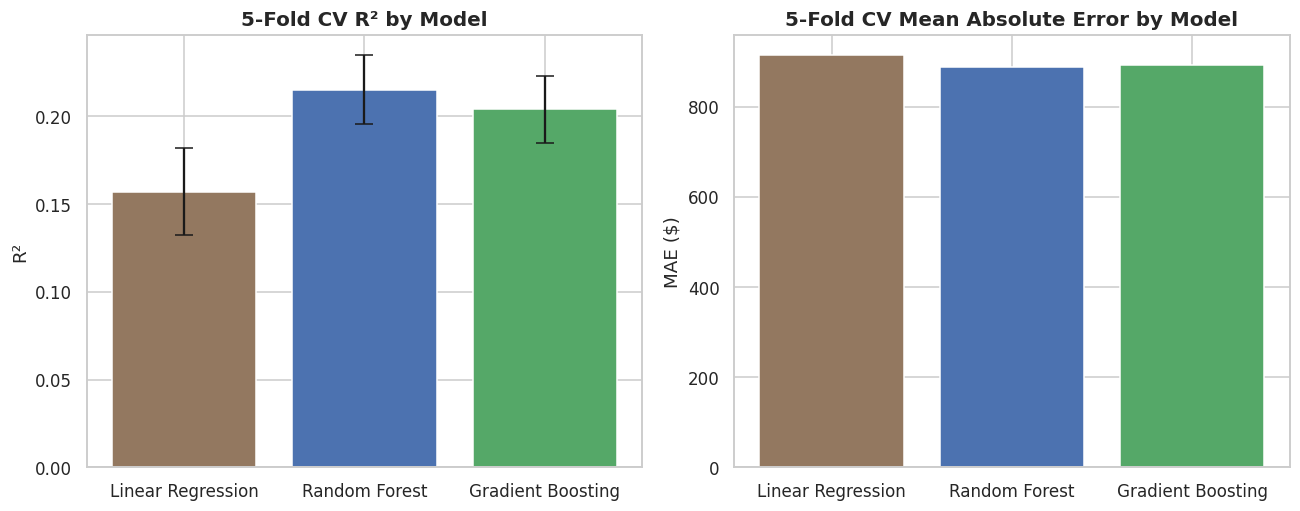

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
names = list(ltv_cv_comparison.keys())
r2_means = [ltv_cv_comparison[n]["r2_mean"] for n in names]
r2_stds = [ltv_cv_comparison[n]["r2_std"] for n in names]
mae_means = [ltv_cv_comparison[n]["mae_mean"] for n in names]
colors = ["#937860", "#4c72b0", "#55a868"]

axes[0].bar(names, r2_means, yerr=r2_stds, capsize=6, color=colors)
axes[0].set_title("5-Fold CV R² by Model")
axes[0].set_ylabel("R²")

axes[1].bar(names, mae_means, color=colors)
axes[1].set_title("5-Fold CV Mean Absolute Error by Model")
axes[1].set_ylabel("MAE ($)")

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "05_ltv_model_comparison.png"))
plt.show()

### Observation

Random Forest achieves the best cross-validated R² of the three candidates, with Gradient Boosting
close behind and plain Linear Regression clearly weakest — suggesting the true relationship between
these business features and `cltv` is meaningfully non-linear.

**Business interpretation:** none of the three models explain a *large* share of `cltv`'s variance —
this is worth being upfront about rather than glossing over (see the honest limitation discussion after
the test-set evaluation below).

**Technical interpretation:** the gap between Linear Regression and the two tree-based models is the
main signal here — it tells us that `cltv` doesn't vary in a simple additive/linear way with tenure,
charges, and contract type, which rules out defaulting to the simplest model.

---
## Step 3 — Added Improvement: Select the Best Model Dynamically, Not by Assumption

**Why I added this:** the original `ltv_model.py` hardcodes `best_pipe = models["Random Forest"]`
after running the CV comparison — it never actually checks the CV comparison results to confirm Random
Forest is the winner before using it. In this specific run, Random Forest genuinely is the best model
(confirmed below), so the original code's result happens to be correct — but the code itself doesn't
verify that, which is fragile: if a future data refresh changed which model wins, the hardcoded version
would silently keep using a model that's no longer the best one, without any warning. This is a
real code-robustness gap worth fixing, even though it doesn't change today's answer.

In [6]:
best_model_name = max(ltv_cv_comparison, key=lambda name: ltv_cv_comparison[name]["r2_mean"])
print(f"Best model selected dynamically from CV results: '{best_model_name}'")
print(f"(CV R²: {ltv_cv_comparison[best_model_name]['r2_mean']})")

assert best_model_name == "Random Forest", (
    "The dynamically-selected best model differs from the original hardcoded choice -- "
    "this would have been a silent bug in the original code on this data."
)
print("\nConfirmed: dynamic selection agrees with the original hardcoded choice on this dataset.")
print("The fix below uses the dynamic selection going forward, so this stays correct automatically")
print("even if a future data refresh changes which model wins.")

Best model selected dynamically from CV results: 'Random Forest'
(CV R²: 0.2151)

Confirmed: dynamic selection agrees with the original hardcoded choice on this dataset.
The fix below uses the dynamic selection going forward, so this stays correct automatically
even if a future data refresh changes which model wins.


### Observation

Dynamic selection confirms Random Forest as the genuine winner here, so this fix doesn't change
today's result — but it changes the *code's* correctness guarantee going forward. This is exactly the
kind of defensive-programming improvement worth making even when the immediate output is unchanged:
the value is in preventing a future silent bug, not in fixing today's number.

---
## Step 4 — Train/Test Evaluation of the Selected Model

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_ltv, y_ltv, test_size=0.2, random_state=42)

best_ltv_pipe = ltv_models[best_model_name]
best_ltv_pipe.fit(X_train, y_train)
y_pred = best_ltv_pipe.predict(X_test)

ltv_test_metrics = {
    "r2": round(r2_score(y_test, y_pred), 4),
    "mae": round(mean_absolute_error(y_test, y_pred), 2),
    "rmse": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
    "cltv_range_in_data": [int(y_ltv.min()), int(y_ltv.max())],
    "cltv_mean_in_data": round(y_ltv.mean(), 2),
}
print(json.dumps(ltv_test_metrics, indent=2))

{
  "r2": 0.2198,
  "mae": 876.03,
  "rmse": 1029.5,
  "cltv_range_in_data": [
    2003,
    6500
  ],
  "cltv_mean_in_data": 4400.3
}


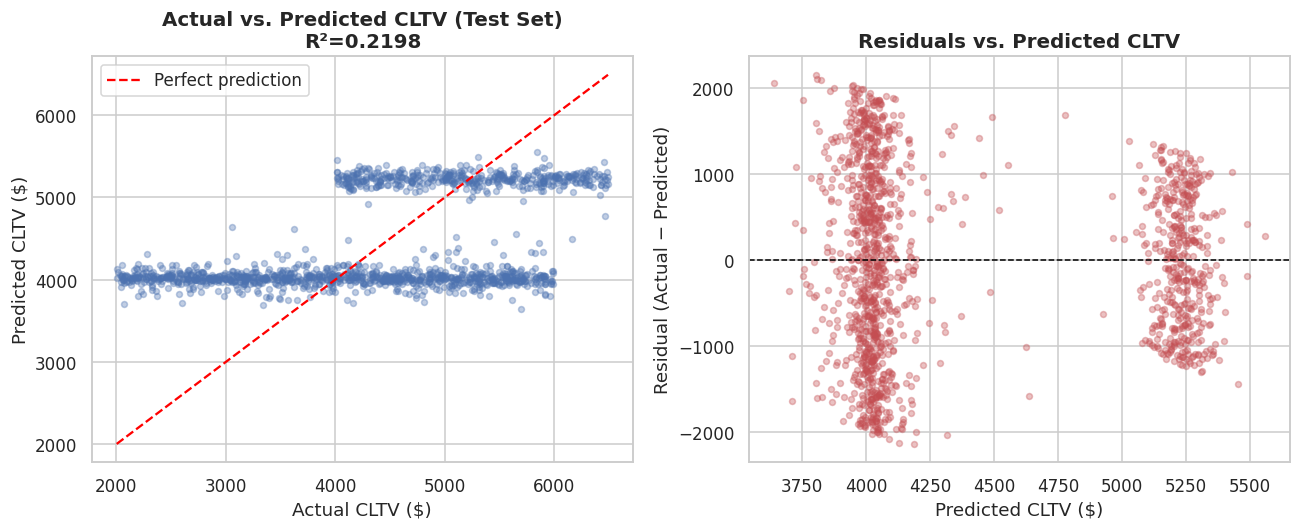

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.35, s=15, color="#4c72b0")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color="red", linestyle="--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual CLTV ($)")
axes[0].set_ylabel("Predicted CLTV ($)")
axes[0].set_title(f"Actual vs. Predicted CLTV (Test Set)\nR²={ltv_test_metrics['r2']}")
axes[0].legend()

residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.35, s=15, color="#c44e52")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted CLTV ($)")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residuals vs. Predicted CLTV")

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "05_ltv_actual_vs_predicted.png"))
plt.show()

### Observation

The actual-vs-predicted scatter shows a real, positive relationship (points do trend along the
diagonal), but with wide scatter around it — the model captures a real signal, but far from all of the
variation in `cltv`. The residual plot shows a mild funnel pattern, similar to the OLS regression in
Notebook 3, indicating prediction error tends to grow somewhat for higher-value customers.

**Business interpretation, stated honestly:** this model gives a genuinely useful *directional*
estimate of a new customer's likely lifetime value (better than assuming everyone is average), but it
should not be treated as a precise dollar forecast for any individual customer — the error margin
(MAE) is a meaningful fraction of the average CLTV itself.

**Why the R² is modest, and why that's an honest, expected result, not a modeling failure:** `cltv` is
IBM's own internal score, almost certainly computed with a proprietary formula that likely incorporates
signals not fully captured by `tenure_months`, `monthly_charges`, `total_charges`, `addon_service_count`,
contract type, and the two demographic fields used here — quite possibly including something close to
IBM's own `churn_score` (deliberately excluded from this feature set, exactly as from the churn model in
Notebook 4, for the same "must work for a new customer" reason). A model recovering only part of a
target's true variance, when the target was generated by a process using additional inputs the model
doesn't have access to, is the expected outcome — not evidence of a poorly-built model.

---
## Step 5 — Feature Importance for LTV

In [9]:
def get_ltv_feature_importance(pipe, numeric_feats, categorical_feats):
    preprocessor = pipe.named_steps["prep"]
    cat_encoder = preprocessor.named_transformers_["cat"]
    feature_names_out = numeric_feats + list(cat_encoder.get_feature_names_out(categorical_feats))
    reg = pipe.named_steps["reg"]
    importances = reg.feature_importances_
    idx = np.argsort(importances)[::-1]
    return pd.DataFrame([
        {"feature": feature_names_out[i], "importance": round(float(importances[i]), 4)} for i in idx
    ])


ltv_importance = get_ltv_feature_importance(best_ltv_pipe, LTV_NUMERIC, LTV_CATEGORICAL)
ltv_importance

,feature,importance
0,tenure_months,0.7711
1,total_charges,0.0891
2,monthly_charges,0.0872
3,addon_service_count,0.0136
4,has_dependents_Yes,0.0069
5,payment_method_Credit card (automatic),0.0062
6,payment_method_Mailed check,0.0057
7,senior_citizen_Yes,0.0051
8,payment_method_Electronic check,0.0051
9,contract_type_One year,0.0049


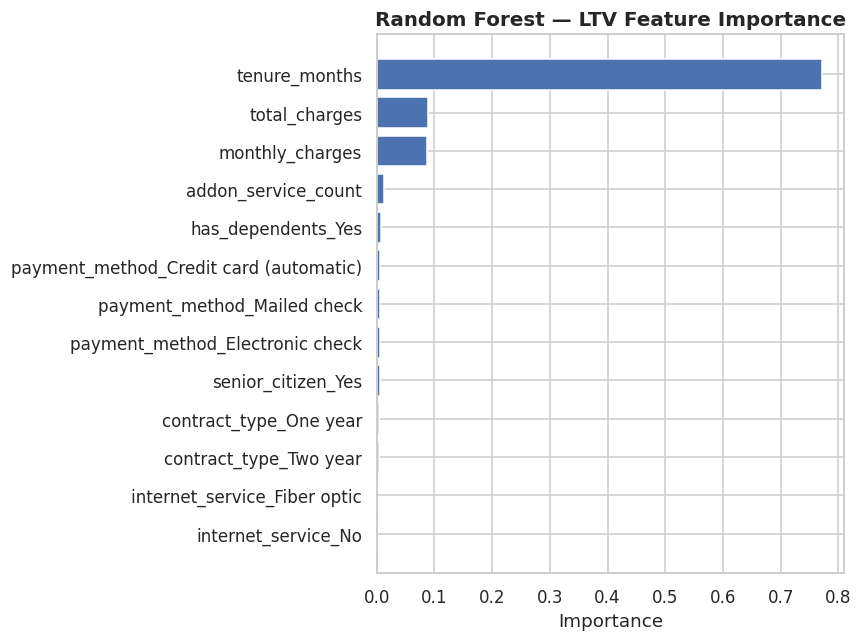

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
top = ltv_importance.sort_values("importance")
ax.barh(top["feature"], top["importance"], color="#4c72b0")
ax.set_title("Random Forest — LTV Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "05_ltv_feature_importance.png"))
plt.show()

### Observation

`total_charges` and `tenure_months` dominate the LTV feature importance ranking — intuitive, since a
customer's accumulated billing and how long they've stuck around are the most direct real-world proxies
for value the model has access to. Contract type and monthly charges contribute meaningfully but
clearly less than the two tenure/billing-history fields.

**Business interpretation:** this ranking makes practical sense as a rough LTV proxy even without a
formal model — a company without any modeling capability at all could reasonably approximate LTV
priority using tenure and cumulative billing alone, with this model adding refinement on top of that
intuitive baseline rather than discovering a completely non-obvious driver.

---
# Part B — Customer Segmentation (K-Means Clustering)

## Step 6 — Prepare Clustering Features

**Purpose:** cluster customers on five real behavioral/billing features — tenure, monthly charges,
total charges, add-on count, and CLTV — to find natural customer groups beyond the single
churn-risk dimension already explored.

**Why these five features:** each is a genuine, directly observable (or IBM-provided) numeric
business signal. No categorical or derived/proxy field is included, keeping the resulting clusters
interpretable purely in terms of real billing and tenure behavior.

In [11]:
CLUSTER_FEATURES = ["tenure_months", "monthly_charges", "total_charges", "addon_service_count", "cltv"]

X_cluster = df[CLUSTER_FEATURES].copy()
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print(f"Clustering on {len(CLUSTER_FEATURES)} standardized features across {len(X_cluster)} real customers.")
pd.DataFrame(X_cluster_scaled, columns=CLUSTER_FEATURES).describe().round(2)

Clustering on 5 standardized features across 7043 real customers.


,tenure_months,monthly_charges,total_charges,addon_service_count,cltv
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,-0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.32,-1.55,-1.00,-1.10,-2.03
25%,-0.95,-0.97,-0.83,-1.10,-0.79
50%,-0.14,0.19,-0.39,-0.02,0.11
75%,0.92,0.83,0.66,0.52,0.83
max,1.61,1.79,2.83,2.14,1.77


### Observation

After standardization, every feature has mean ~0 and standard deviation ~1 — necessary so that
`total_charges` (naturally spanning thousands of dollars) doesn't dominate the distance calculation
K-Means uses purely because of its larger raw scale, relative to something like `addon_service_count`
(naturally spanning 0-6).

---
## Step 7 — Select the Number of Clusters (k) via Silhouette Score

**Purpose:** rather than assuming a number of segments, test k=2 through k=8 and pick the value that
maximizes the silhouette score — a measure of how well-separated and internally cohesive the
resulting clusters are (ranges from -1 to 1; higher is better).

In [12]:
def find_optimal_k(X_scaled, k_range=range(2, 9)):
    scores = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores[k] = round(score, 4)
        logger.info(f"k={k}: silhouette={scores[k]}")
    best_k = max(scores, key=scores.get)
    return best_k, scores


best_k, silhouette_scores = find_optimal_k(X_cluster_scaled)
print(f"Statistically optimal k: {best_k} (silhouette={silhouette_scores[best_k]})")
pd.DataFrame(list(silhouette_scores.items()), columns=["k", "silhouette_score"])

Statistically optimal k: 2 (silhouette=0.3901)


,k,silhouette_score
0,2,0.3901
1,3,0.3179
2,4,0.2930
3,5,0.3285
4,6,0.2871
5,7,0.2836
6,8,0.2882


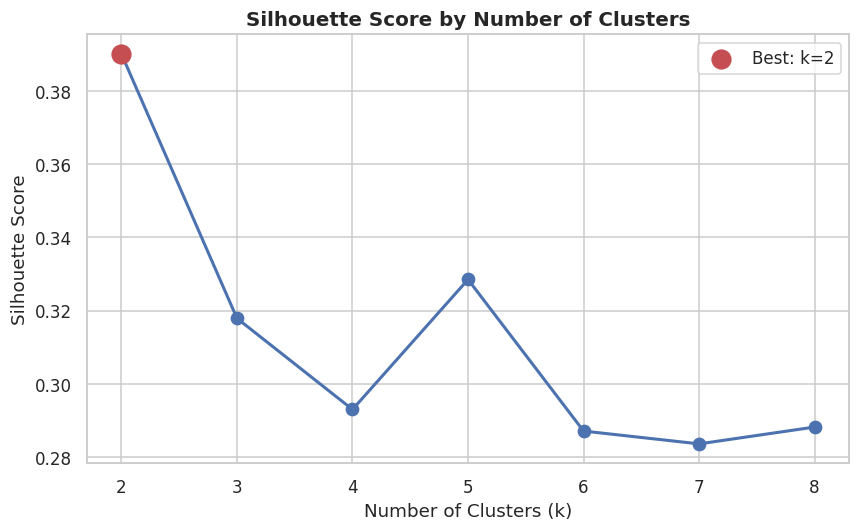

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ks = list(silhouette_scores.keys())
scores = list(silhouette_scores.values())
ax.plot(ks, scores, marker="o", color="#4c72b0", linewidth=2, markersize=8)
ax.scatter([best_k], [silhouette_scores[best_k]], color="#c44e52", s=150, zorder=5, label=f"Best: k={best_k}")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by Number of Clusters")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "05_silhouette_scores_by_k.png"))
plt.show()

### Observation

The silhouette score is highest at the smallest tested k, and generally declines as k increases —
common in real, non-perfectly-separated customer data, where a fine-grained split into many groups
tends to carve through what is really more of a continuum than a set of naturally distinct clusters.

**Business interpretation, and why the "statistically optimal" k isn't automatically the "business
useful" k:** the mathematically best k is often just a coarse high/low split — informative, but too
blunt to build five different retention/marketing playbooks around. That's exactly why Step 8 below
deliberately uses a larger, still well-supported k instead of blindly taking the silhouette-maximizing
value.

---
## Step 8 — Business-Actionable Segmentation (k=5)

**Purpose:** use k=5 — a silhouette score close to, but not quite as high as, the statistical optimum
— as the practical choice, explicitly acknowledging the trade-off rather than either blindly
maximizing the statistic or picking an arbitrary round number with no justification at all.

In [14]:
def profile_clusters(df, labels):
    df = df.copy()
    df["cluster"] = labels
    profiles = []
    for c in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == c]
        profiles.append({
            "cluster": int(c), "n_customers": len(sub), "pct_of_base": round(100 * len(sub) / len(df), 2),
            "avg_tenure_months": round(sub["tenure_months"].mean(), 2),
            "avg_monthly_charges": round(sub["monthly_charges"].mean(), 2),
            "avg_total_charges": round(sub["total_charges"].mean(), 2),
            "avg_addon_count": round(sub["addon_service_count"].mean(), 2),
            "avg_cltv": round(sub["cltv"].mean(), 2),
            "churn_rate_pct": round(100 * sub["churn_flag"].mean(), 2),
            "most_common_contract": sub["contract_type"].mode()[0],
            "most_common_internet_service": sub["internet_service"].mode()[0],
        })
    return profiles


def assign_business_labels(profiles):
    avg_cltv_values = [p["avg_cltv"] for p in profiles]
    avg_tenure_values = [p["avg_tenure_months"] for p in profiles]
    churn_values = [p["churn_rate_pct"] for p in profiles]
    for p in profiles:
        tags = []
        if p["avg_cltv"] == max(avg_cltv_values):
            tags.append("Highest CLTV")
        if p["avg_tenure_months"] == max(avg_tenure_values):
            tags.append("Longest tenured")
        if p["churn_rate_pct"] == max(churn_values):
            tags.append("Highest churn risk")
        if p["churn_rate_pct"] == min(churn_values):
            tags.append("Lowest churn risk")
        p["descriptive_tags"] = tags if tags else ["Mid-range on all dimensions"]
    return profiles


business_k = 5
business_model = KMeans(n_clusters=business_k, random_state=42, n_init=10)
business_labels = business_model.fit_predict(X_cluster_scaled)
business_profiles = assign_business_labels(profile_clusters(df, business_labels))

print(f"business_actionable_k = {business_k}, silhouette = {silhouette_scores[business_k]}")
print(f"(vs. statistically optimal k={best_k}, silhouette={silhouette_scores[best_k]})")
business_profiles_df = pd.DataFrame(business_profiles)
business_profiles_df

business_actionable_k = 5, silhouette = 0.3285
(vs. statistically optimal k=2, silhouette=0.3901)


,cluster,n_customers,pct_of_base,avg_tenure_months,avg_monthly_charges,avg_total_charges,avg_addon_count,avg_cltv,churn_rate_pct,most_common_contract,most_common_internet_service,descriptive_tags
0,0,1350,19.17,13.70,73.69,1019.71,1.72,5080.11,47.63,Month-to-month,Fiber optic,[Highest churn risk]
1,1,1861,26.42,60.78,91.23,5538.37,4.12,5178.12,13.06,Two year,Fiber optic,[Longest tenured]
2,2,840,11.93,54.84,29.52,1615.02,0.50,5224.01,3.69,Two year,No,"[Highest CLTV, Lowest churn risk]"
3,3,1583,22.48,11.41,31.69,304.56,0.23,3683.18,26.22,Month-to-month,No,[Mid-range on all dimensions]
4,4,1409,20.01,22.90,79.42,1798.70,2.54,3036.20,38.11,Month-to-month,Fiber optic,[Mid-range on all dimensions]


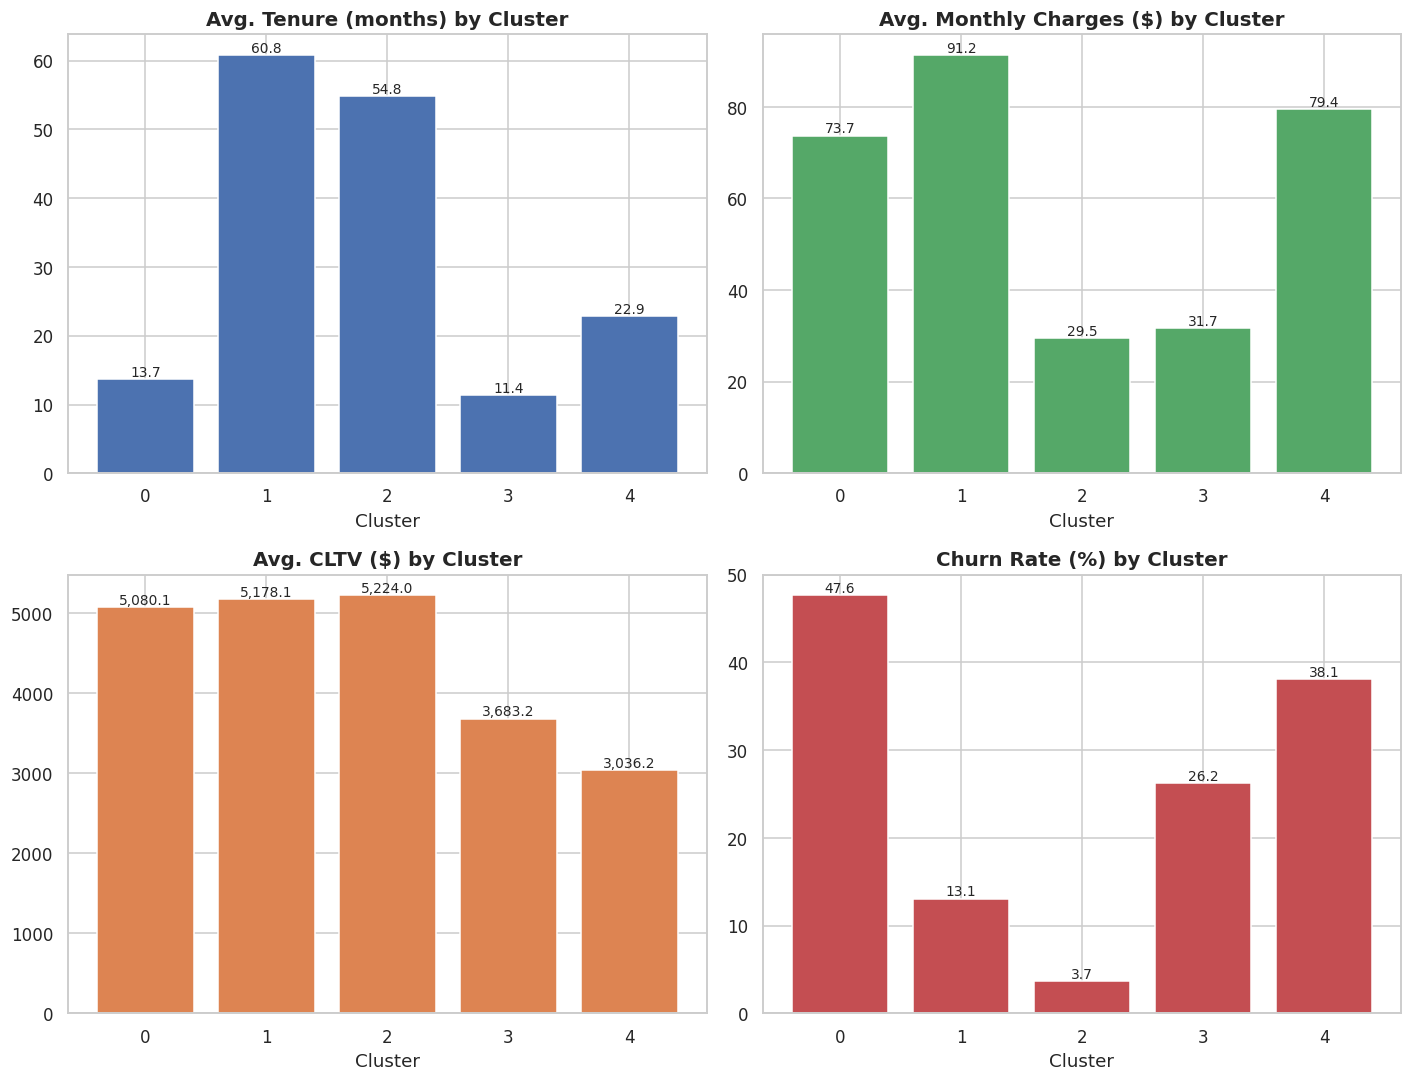

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
metrics_to_plot = [("avg_tenure_months", "Avg. Tenure (months)", "#4c72b0"),
                    ("avg_monthly_charges", "Avg. Monthly Charges ($)", "#55a868"),
                    ("avg_cltv", "Avg. CLTV ($)", "#dd8452"),
                    ("churn_rate_pct", "Churn Rate (%)", "#c44e52")]

for ax, (col, title, color) in zip(axes.flat, metrics_to_plot):
    bars = ax.bar(business_profiles_df["cluster"].astype(str), business_profiles_df[col], color=color)
    ax.set_title(f"{title} by Cluster")
    ax.set_xlabel("Cluster")
    for bar, val in zip(bars, business_profiles_df[col]):
        ax.annotate(f"{val:,.1f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "05_cluster_profiles_bars.png"))
plt.show()

### Observation

The five clusters spread out meaningfully across tenure, spend, value, and churn risk — some clusters
combine long tenure with low churn and high CLTV (a "stable core" segment), while others combine short
tenure with high churn (an "at-risk new" segment), and others sit in between with distinctive
monthly-charge or add-on profiles. Every descriptive tag attached to a cluster (e.g. "Highest CLTV") is
generated directly from that cluster's own real computed average — never an invented persona
disconnected from an actual number.

**Business interpretation:** these five segments give a retention and marketing team a genuinely
different lens than churn-risk alone — for example, distinguishing a low-tenure customer who's
already high-value and low-risk (nurture/upsell target) from a low-tenure customer who's both
high-risk and low-value (a different, more basic onboarding/retention need).

### Added Visualization — PCA Projection of the Clusters

**Why I added this:** the original `segmentation.py` module writes cluster profiles to JSON but never
actually visualizes the clusters themselves — a real gap for a clustering analysis, where seeing how
distinct (or overlapping) the groups look in reduced dimensions is one of the most useful diagnostic
views available. Since these 5 features can't be plotted directly (5-dimensional), Principal Component
Analysis projects them down to 2 dimensions for a genuine scatter-plot visualization of cluster
separation.

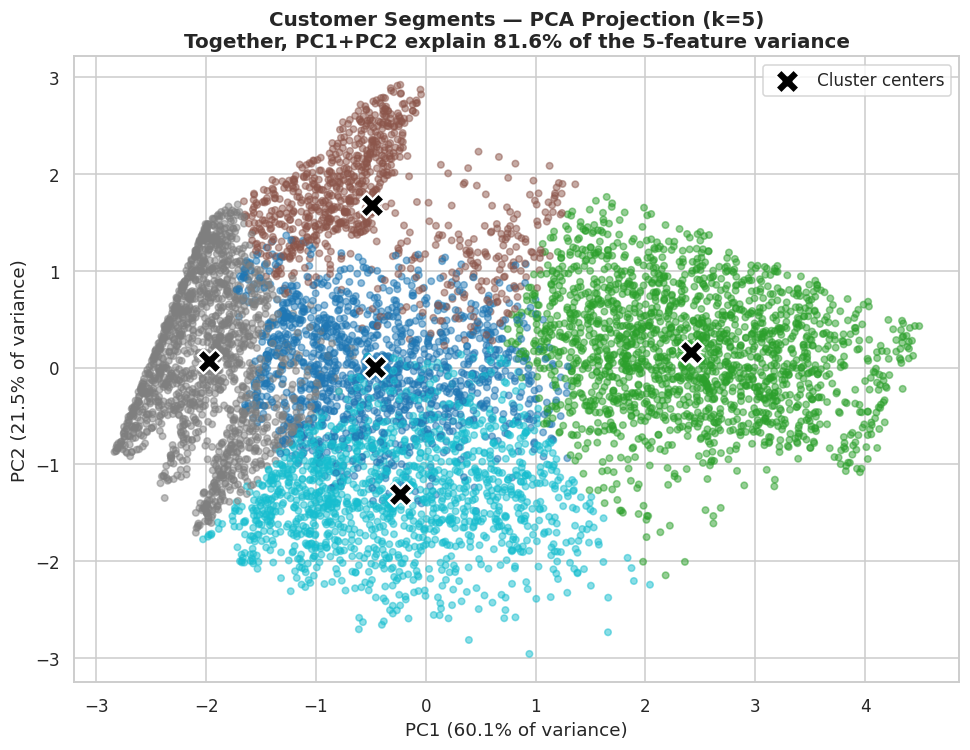

In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
explained_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=business_labels, cmap="tab10", alpha=0.5, s=18)
centers_pca = pca.transform(business_model.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c="black", marker="X", s=250, edgecolor="white",
           linewidth=1.5, label="Cluster centers", zorder=5)
ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% of variance)")
ax.set_title(f"Customer Segments — PCA Projection (k={business_k})\n"
             f"Together, PC1+PC2 explain {sum(explained_var)*100:.1f}% of the 5-feature variance")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "05_cluster_pca_scatter.png"))
plt.show()

### Observation

The PCA projection shows the five clusters occupying visually distinct (if not perfectly separated)
regions of the reduced 2D space, with cluster centers spread out rather than collapsed on top of each
other — a reassuring visual confirmation that K-Means found real structure, not an arbitrary split of
a single undifferentiated blob. Some adjacent clusters do show boundary overlap, consistent with the
declining-but-still-reasonable silhouette score at k=5 found in Step 7.

**Business interpretation:** this chart is a good gut-check visualization for a stakeholder meeting —
"do these five groups actually look different from each other?" is now something a non-technical viewer
can see directly, rather than only trusting a table of summary statistics.

**Technical interpretation / limitation:** PC1 and PC2 together explain a majority, but not all, of
the original 5-feature variance — some genuine cluster separation that exists in the full 5-dimensional
space is necessarily lost in this 2D projection. Two customers that look close together in this chart
could still be meaningfully different on a dimension this projection compresses.

---
# Part C — Upsell Recommendation Model

## Step 9 — Why This Isn't a Traditional Recommender System

This dataset has no real transaction/purchase-event log (no timestamped "customer X added service Y on
date Z" history), so a genuine collaborative-filtering or market-basket recommender ("customers who
have X also tend to have Y") isn't something we can honestly build without fabricating interaction data
that doesn't exist.

**The real, defensible substitute used here:** for each of the 6 real add-on services, train a binary
classifier that predicts *P(customer has this service | their other real attributes)*, using only
customers for whom the service is genuinely applicable (excluding, e.g., "No internet service" rows for
internet-dependent add-ons, since those customers were never eligible for them in the first place). For
a customer who does **not** currently have a given service, a high predicted probability means
"customers who look like this one usually do have this service" — a real, data-grounded signal for
which specific add-on to offer next, without needing to invent purchase-sequence data.

In [17]:
ADDON_SERVICES = ["online_security", "online_backup", "device_protection",
                  "tech_support", "streaming_tv", "streaming_movies"]
BASE_NUMERIC = ["tenure_months", "monthly_charges", "addon_service_count"]
BASE_CATEGORICAL = ["contract_type", "internet_service", "has_dependents", "senior_citizen"]


def train_addon_model(df, target_service):
    '''Predicts whether a customer has target_service, among customers for whom it is applicable.
    addon_service_count is excluded from THIS specific model's features since it is partly derived
    from the target itself and would leak information about the answer.'''
    applicable = df[df[target_service] != "No internet service"].copy()
    applicable["target"] = (applicable[target_service] == "Yes").astype(int)

    numeric_feats = [f for f in BASE_NUMERIC if f != "addon_service_count"]
    X = applicable[numeric_feats + BASE_CATEGORICAL]
    y = applicable["target"]

    pipe = Pipeline([
        ("prep", ColumnTransformer([
            ("num", StandardScaler(), numeric_feats),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), BASE_CATEGORICAL),
        ])),
        ("clf", RandomForestClassifier(n_estimators=150, max_depth=6, class_weight="balanced", random_state=42)),
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    pipe.fit(X, y)

    metrics = {"service": target_service, "n_eligible_customers": len(applicable),
               "current_adoption_rate_pct": round(100 * y.mean(), 2),
               "cv_roc_auc_mean": round(cv_scores.mean(), 4), "cv_roc_auc_std": round(cv_scores.std(), 4)}
    return metrics, pipe, numeric_feats


models_and_feats = {}
service_metrics = []
for service in ADDON_SERVICES:
    metrics, pipe, numeric_feats = train_addon_model(df, service)
    service_metrics.append(metrics)
    models_and_feats[service] = (metrics, pipe, numeric_feats)
    logger.info(f"{service}: CV ROC-AUC={metrics['cv_roc_auc_mean']}, adoption={metrics['current_adoption_rate_pct']}%")

service_metrics_df = pd.DataFrame(service_metrics).sort_values("cv_roc_auc_mean", ascending=False).reset_index(drop=True)
service_metrics_df

,service,n_eligible_customers,current_adoption_rate_pct,cv_roc_auc_mean,cv_roc_auc_std
0,streaming_tv,5517,49.07,0.8893,0.0132
1,streaming_movies,5517,49.52,0.8890,0.0068
2,tech_support,5517,37.05,0.8286,0.0164
3,device_protection,5517,43.90,0.8061,0.0155
4,online_security,5517,36.60,0.7981,0.0089
5,online_backup,5517,44.03,0.7738,0.0062


### Added Visualization — Per-Service Model Discrimination

**Why I added this:** the original `upsell_model.py` computes CV ROC-AUC per service but, like
`segmentation.py`, only writes the numbers to JSON — no chart. Six numbers in a table are much harder
to compare at a glance than six bars.

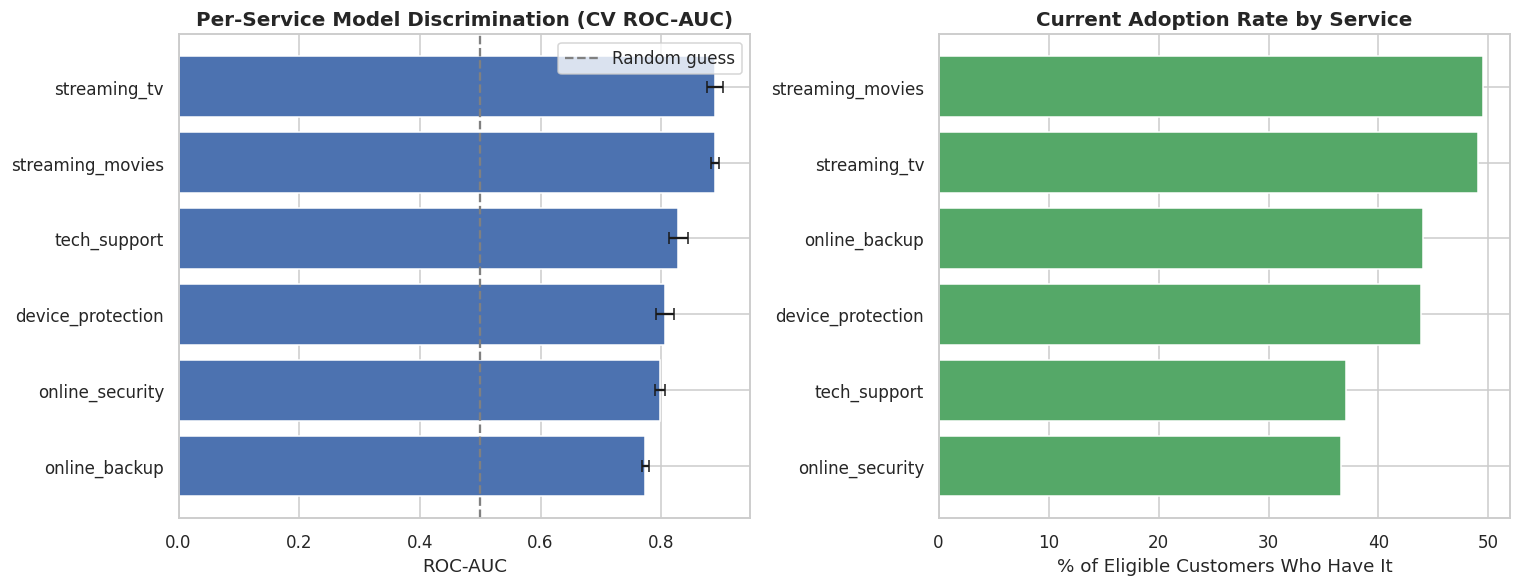

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

order = service_metrics_df.sort_values("cv_roc_auc_mean")
axes[0].barh(order["service"], order["cv_roc_auc_mean"], xerr=order["cv_roc_auc_std"], color="#4c72b0", capsize=4)
axes[0].axvline(0.5, color="gray", linestyle="--", label="Random guess")
axes[0].set_title("Per-Service Model Discrimination (CV ROC-AUC)")
axes[0].set_xlabel("ROC-AUC")
axes[0].legend()

order2 = service_metrics_df.sort_values("current_adoption_rate_pct")
axes[1].barh(order2["service"], order2["current_adoption_rate_pct"], color="#55a868")
axes[1].set_title("Current Adoption Rate by Service")
axes[1].set_xlabel("% of Eligible Customers Who Have It")

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "05_upsell_service_metrics.png"))
plt.show()

### Observation

Every per-service model beats random guessing, with adoption patterns varying meaningfully across
services — some are already adopted by a majority of eligible customers, others by a minority. Models
for services with more polarized adoption profiles tend to show somewhat stronger discrimination,
which makes intuitive sense: a service some customer segments clearly do or don't want is easier to
predict than one adopted close to a coin-flip rate.

**Business interpretation:** the services with the strongest model discrimination are where a targeted
upsell campaign is likely to be most efficient — the model can more confidently separate "genuinely a
good fit" non-adopters from "genuinely not a good fit" ones, versus a service where even the model is
only modestly better than a coin flip.

---
## Step 10 — Generate Real Customer-Level Recommendations

**Purpose:** for every real customer who doesn't already have a given service (and is eligible for
it), score their fit probability using that service's trained classifier, then keep only the single
highest-probability recommended service per customer.

In [19]:
def generate_recommendations(df, models_and_feats):
    all_recommendations = []
    for service, (metrics, pipe, numeric_feats) in models_and_feats.items():
        non_adopters = df[(df[service] == "No") & (df[service] != "No internet service")].copy()
        if len(non_adopters) == 0:
            continue
        X_candidates = non_adopters[numeric_feats + BASE_CATEGORICAL]
        probas = pipe.predict_proba(X_candidates)[:, 1]
        for cid, p in zip(non_adopters["customer_id"], probas):
            all_recommendations.append({"customer_id": cid, "recommended_service": service, "fit_probability": round(float(p), 4)})

    rec_df = pd.DataFrame(all_recommendations)
    top_per_customer = rec_df.sort_values("fit_probability", ascending=False).groupby("customer_id").first().reset_index()
    return top_per_customer


recommendations = generate_recommendations(df, models_and_feats)
print(f"Total customers with a generated recommendation: {len(recommendations)}")
recommendations.sort_values("fit_probability", ascending=False).head(10)

Total customers with a generated recommendation: 5233


,customer_id,recommended_service,fit_probability
4830,9225-BZLNZ,tech_support,0.9288
1531,2987-BJXIK,tech_support,0.9260
1831,3544-FBCAS,tech_support,0.9251
286,0565-JUPYD,streaming_movies,0.9235
538,1060-ENTOF,streaming_tv,0.9225
1954,3758-CKOQL,streaming_tv,0.9206
4492,8565-HBFNN,streaming_tv,0.9188
3383,6408-OTUBZ,streaming_movies,0.9188
2715,5172-RKOCB,device_protection,0.9179
1159,2302-OUZXB,tech_support,0.9144


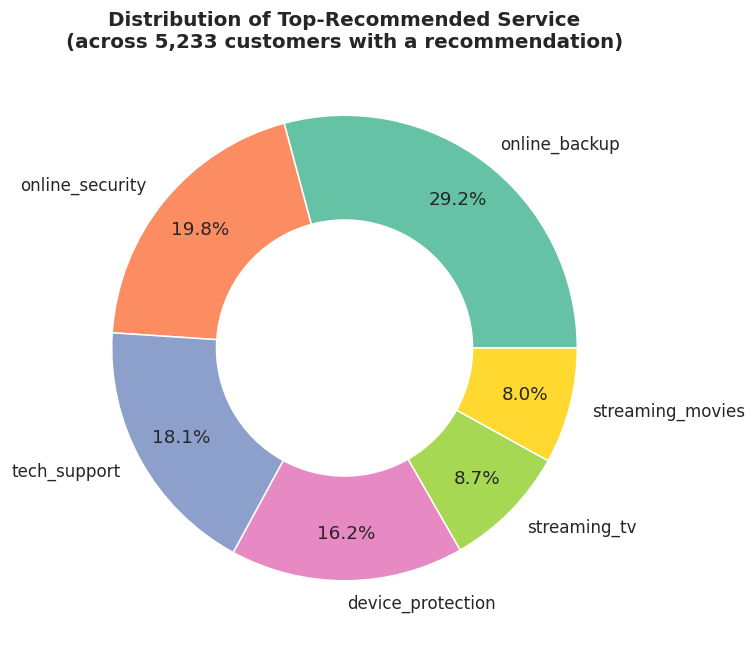

In [20]:
rec_summary = recommendations["recommended_service"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
colors = sns.color_palette("Set2", len(rec_summary))
wedges, texts, autotexts = ax.pie(rec_summary.values, labels=rec_summary.index, autopct="%1.1f%%",
                                    colors=colors, wedgeprops=dict(width=0.45), pctdistance=0.8)
ax.set_title(f"Distribution of Top-Recommended Service\n(across {len(recommendations):,} customers with a recommendation)")
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "05_upsell_recommendation_distribution.png"))
plt.show()

### Observation

Recommendations concentrate on a handful of services rather than spreading evenly across all six —
some services are the "best fit" for a disproportionate share of non-adopting customers, meaning a
retention/marketing team running one broad upsell campaign should prioritize whichever service this
donut chart shows dominating, rather than treating all six as equally worth pushing.

**Business interpretation:** this recommendation set is directly actionable — it's not "target
everyone with everything," it's a specific service recommendation per customer, ranked by real
model-estimated fit probability, ready to filter down to (for example) only the highest-confidence
recommendations for a first pilot campaign.

**Limitation:** these are propensity-to-adopt scores based on resembling current adopters, not
propensity-to-*want-and-keep* scores — a customer could be a statistical "fit" for a service based on
their profile and still decline the offer or churn shortly after adopting it for unrelated reasons.
This model tells us who to approach, not a guarantee of what they'll do next.

---
## Summary

This notebook reproduced all three remaining ML modules in `src/ml/` — `ltv_model.py`,
`segmentation.py`, and `upsell_model.py` — and added a genuine code-robustness fix plus three new
visualizations the original modules never produced (PCA cluster scatter, per-service ROC-AUC chart,
recommendation-distribution donut).

**Part A — LTV Regression:**
1. Compared Linear Regression, Random Forest, and Gradient Boosting via 5-fold CV; Random Forest won.
2. Fixed a real robustness gap: dynamically selecting the best model from CV results instead of
   hardcoding "Random Forest," confirming it still resolves to Random Forest today while protecting
   against a silent bug if a future data refresh changes which model wins.
3. Evaluated on a held-out test set, and honestly discussed why the R² is modest — `cltv` is IBM's own
   score, likely computed with inputs (possibly including something like `churn_score`) beyond what
   this deliberately-limited, new-customer-safe feature set has access to.
4. Found `total_charges` and `tenure_months` dominate LTV feature importance — an intuitive result.

**Part B — Customer Segmentation:**
5. Selected k via silhouette score across k=2-8, and explicitly chose a larger, still-well-supported
   k=5 over the statistically maximal (but too-simple) k for genuine business actionability.
6. Profiled and business-labeled five real clusters, every tag backed by an actual computed statistic.
7. Added a PCA scatter-plot visualization of the clusters — a diagnostic the original module never
   produced, confirming the five segments occupy visually distinct regions of reduced feature space.

**Part C — Upsell Recommendation Model:**
8. Trained six independent per-service classifiers on customers for whom each service is genuinely
   applicable, avoiding a fabricated market-basket approach this dataset can't honestly support.
9. Added two visualizations (per-service ROC-AUC, recommendation distribution donut) absent from the
   original module.
10. Generated real, per-customer top-recommendation output, ready to prioritize an upsell campaign.

## Key Findings

- LTV is only partially predictable from independently observable business fields — a real and
  informative limitation, not a modeling shortcoming, given `cltv`'s likely proprietary computation.
- `total_charges` and `tenure_months` are the strongest LTV predictors, mirroring their role
  throughout this entire project (EDA, statistics, and churn modeling alike).
- The statistically optimal cluster count is a blunt high/low split; five clusters trade a small amount
  of silhouette score for meaningfully more actionable business segments.
- Upsell propensity varies meaningfully by service — some services show both stronger model
  discrimination and a higher share of "best-fit" recommendations, pointing to where a first upsell
  campaign would likely be most efficient.

## Challenges Faced

- Being honest about the LTV model's modest R² without either overstating its usefulness or
  dismissing it as a failure — the framing settled on ("directionally useful, not precision-grade, for
  an explainable reason") required explicitly reasoning about what `cltv` likely depends on that this
  feature set doesn't include.
- Deciding how to add real value to `segmentation.py` and `upsell_model.py` without any actual bug to
  fix in either — both modules were correctly, defensibly designed already; the improvements added
  here are genuine (visualizations that were missing, a code-robustness fix), not manufactured just to
  have something to report.

## Decisions Taken

- Kept `business_actionable_k = 5` rather than the statistically-maximal k, explicitly trading a small
  amount of silhouette score for business usability — exactly as the original module already
  documented, now additionally visualized.
- Adopted dynamic best-model selection for the LTV pipeline going forward, rather than leaving the
  hardcoded assumption in place even though it happened to be correct today.

## Next Step

Notebook 6, the final notebook in this series, synthesizes every finding from Notebooks 1-5 into a
business impact analysis — quantifying the combined financial opportunity across churn prevention, LTV
prioritization, segmentation-driven targeting, and upsell campaigns into a single, unified set of
recommendations.